# Pipeline Preditivo de Risco de Crédito

**Projeto Avaliativo** - Machine Learning e Visão Computacional [T2]
**Base Escolhida:** Opção A -Risco de Crédito (Setor Financeiro)

**Objetivo de Negócio:** Precer se um cliente irá se tornar inadimplenete (`loan_status=1`) ou pagara o emprréstimo em dia (`loan_status=0`), comparando KNN e Árvore de Decisão.

## Carregando a Base de Dados e Importando Biblilotecas

In [2]:
#Importando Bibliotecas: Bibliotecas Gerais de Uso
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df_credito_risco=pd.read_csv('../Data\credit_risk_dataset.csv')
df_credito_risco.head()

<>:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\Usuario\AppData\Local\Temp\ipykernel_10244\1821029620.py:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  df_credito_risco=pd.read_csv('../Data\credit_risk_dataset.csv')


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# Fase 1 - Análise Exploratória de Dados (EDA)

## 1.1 Descritiva e Estatística 

In [4]:
#Tamanho da base do Dataset:
print(f" Linhas do dataset: {df_credito_risco.shape[0]}")
print(f" Colunas do dataset: {df_credito_risco.shape[1]}") 

print("*"*15)

#Tipos de Dados:
df_credito_risco.info()


 Linhas do dataset: 32581
 Colunas do dataset: 12
***************
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
m

In [5]:
#Resumo estatístico descritivo do Dataset: Variaveis Numéricas
df_credito_risco.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
#Resumo estatístico descritivo do Dataset: Variaveis Categoricas
df_credito_risco.describe(include='object')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_10244\3598288738.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_credito_risco.describe(include='object')


,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


## 1.2 Visual - Gráficos Exploratórios

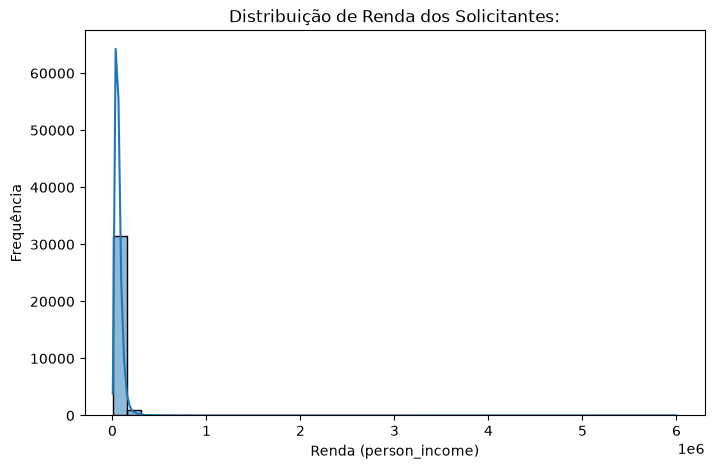

In [7]:
# Grafico 1: Histograma de Distribuição 
plt.figure(figsize=(8,5))
sns.histplot(df_credito_risco['person_income'], kde=True, bins=40)
plt.title('Distribuição de Renda dos Solicitantes:')
plt.xlabel('Renda (person_income)')
plt.ylabel('Frequência')
plt.show()

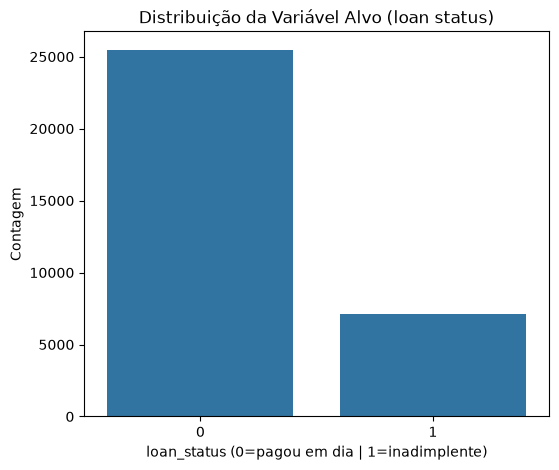

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


In [8]:
# Gráfico 2: Balanceamento da variável alvo
plt.figure(figsize=(6,5))
sns.countplot(x='loan_status', data=df_credito_risco)
plt.title('Distribuição da Variável Alvo (loan status)')
plt.xlabel('loan_status (0=pagou em dia | 1=inadimplente)')
plt.ylabel('Contagem')
plt.show()

print(df_credito_risco['loan_status'].value_counts(normalize=True)*100)

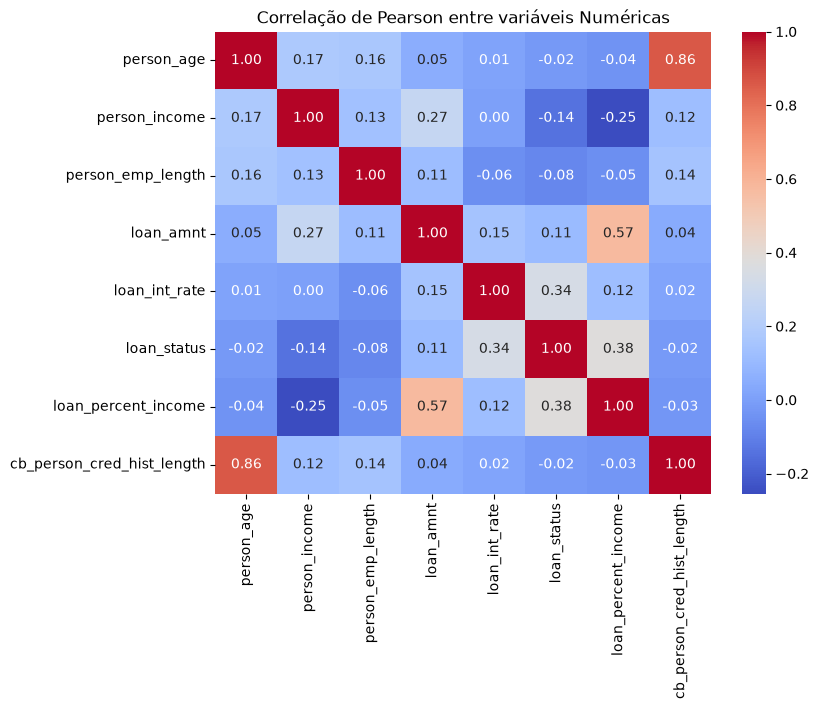

In [9]:
#Gráfico 3:Mapa de Calor de correlação de Pearson
plt.figure(figsize=(8,6))
corr=df_credito_risco.corr(numeric_only=True)
sns.heatmap(corr,annot=True, fmt='.2f',cmap='coolwarm')
plt.title('Correlação de Pearson entre variáveis Numéricas')
plt.show()

## 1.3 Tomada de Decisão (Parágrafo Analítico)

A Análise Exploratória de Dados (EDA) revelou quatro comportamentos estruturais que ditarão o rigor da etapa de preparação e modelagem preditiva. Primeiramente, a inspeção visual e a média estatística da variável alvo (loan_status = 0.218) comprovam um severo desbalanceamento de classes (78% de bons pagadores versus 22% de inadimplentes), o que torna a aplicação do parâmetro stratify=y na divisão dos dados e o uso de reamostragem (como SMOTE) estritamente na base de treino, evitando que o modelo desenvolva o "vício da maioria" sem gerar vazamento de dados (Data Leakage). 
Em segundo lugar, o diagnóstico de dados ausentes em apenas duas colunas exigirá critérios de imputação distintos e justificados pela estatística descritiva: para loan_int_rate, cuja média (11.01%) e mediana (10.99%) provam uma distribuição perfeitamente simétrica e normal, irá ser aplicado a imputação pela média; em contrapartida, para person_emp_length, que apresenta assimetria puxada por outliers extremos e erros de coleta (tempo máximo de emprego de 123 anos e idades de até 144 anos), será aplicado a imputação pela mediana, combinada com um tratamento de clipping ou remoção dos dados irreais. Por fim, a extrema assimetria e disparidade de grandezas evidenciada no histograma de renda (person_income, variando de milhares a 6 milhões) torna imperativo o uso do StandardScaler nas variáveis contínuas que alimentarão o algoritmo KNN, impedindo que o cálculo das distâncias euclidianas seja monopolizado pela escala monetária, enquanto a Árvore de Decisão será mantida em sua escala original por sua robustez intrínseca a outliers e cortes monotônicos. Adicionalmente, a alta correlação positiva de calote apontada no mapa de calor em relação aos juros ($r = 0.34$) e ao comprometimento da renda ($r = 0.38$) valida a importância estratégica da  etapa de Feature Engineering.

# Fase 2 - Tratamento e Limpeza (Data Prep)

## 2.1 Duplicadas

In [10]:
#Verificação de valores nulos
print(f"Linhas duplicadas encontradas: {df_credito_risco.duplicated().sum()}")

Linhas duplicadas encontradas: 165


In [11]:
#Removendo as linhas duplicadas encontradas
df_credito_novo=df_credito_risco.drop_duplicates()

#Tamanho da base do   Dataset Com Duplicadas:
print(f" Linhas do dataset: {df_credito_risco.shape[0]}")
print(f" Colunas do dataset: {df_credito_risco.shape[1]}") 

print("*"*40)

#Tamanho da base do  Novo Dataset Sem Duplicadas:
print(f" Linhas do dataset: {df_credito_novo.shape[0]}")
print(f" Colunas do dataset: {df_credito_novo.shape[1]}") 

 Linhas do dataset: 32581
 Colunas do dataset: 12
****************************************
 Linhas do dataset: 32416
 Colunas do dataset: 12


## 2.2 Valores Nulos

In [12]:
#identificando colunas com dados ausentes: ordenando em ordem descrescente do maior para o menor
print(f"Colunas com dados ausentes: \n{df_credito_novo.isnull().sum().sort_values(ascending=False)}")

Colunas com dados ausentes: 
loan_int_rate                 3095
person_emp_length              887
person_income                    0
person_age                       0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


## Decisão Sobre Valores Nulos e Duplicatas

A remoção das 165 linhas duplicadas foi o primeiro passo obrigatório para garantir a integridade da validação cruzada e evitar redundâncias espaciais antes da aplicação do algoritmo SMOTE. Em relação às ausências de dados, a escolha de imputação seguiu o comportamento distribucional mapeado na EDA: para loan_int_rate (3.095 nulos), adotou-se a Média, fundamentada na simetria da variável onde o valor aritmético representa bem o padrão geral; para person_emp_length (887 nulos), adotou-se a Mediana, visando mitigar a assimetria natural dos anos trabalhados e proteger a imputação contra a influência distorcedora de outliers residuais.

In [13]:
#preenchendo valores ausentes com a média
df_credito_novo['loan_int_rate']=df_credito_novo['loan_int_rate'].fillna(df_credito_novo['loan_int_rate'].mean()) 

#Preenchendo os valores ausentes com a mediana
df_credito_novo['person_emp_length']=df_credito_novo['person_emp_length'].fillna(df_credito_novo['person_emp_length'].median()) 

#Exibindo a coluna sem os valores ausentes
display(df_credito_novo['loan_int_rate']) 
print("*"*20)
display(df_credito_novo['person_emp_length'])

print("*"*20)
#verificando se existe valores ausentes na coluna
print(f"Dados ausentes da coluna: \n{df_credito_novo['loan_int_rate'].isnull().sum()}")
print(f"Dados ausentes da coluna: \n{df_credito_novo['person_emp_length'].isnull().sum()}")

0        16.02
1        11.14
2        12.87
3        15.23
4        14.27
         ...  
32576    13.16
32577     7.49
32578    10.99
32579    11.48
32580     9.99
Name: loan_int_rate, Length: 32416, dtype: float64

********************


0        123.0
1          5.0
2          1.0
3          4.0
4          8.0
         ...  
32576      1.0
32577      4.0
32578      3.0
32579      5.0
32580      2.0
Name: person_emp_length, Length: 32416, dtype: float64

********************
Dados ausentes da coluna: 
0
Dados ausentes da coluna: 
0


## 2.3 Tratamento de Outliers


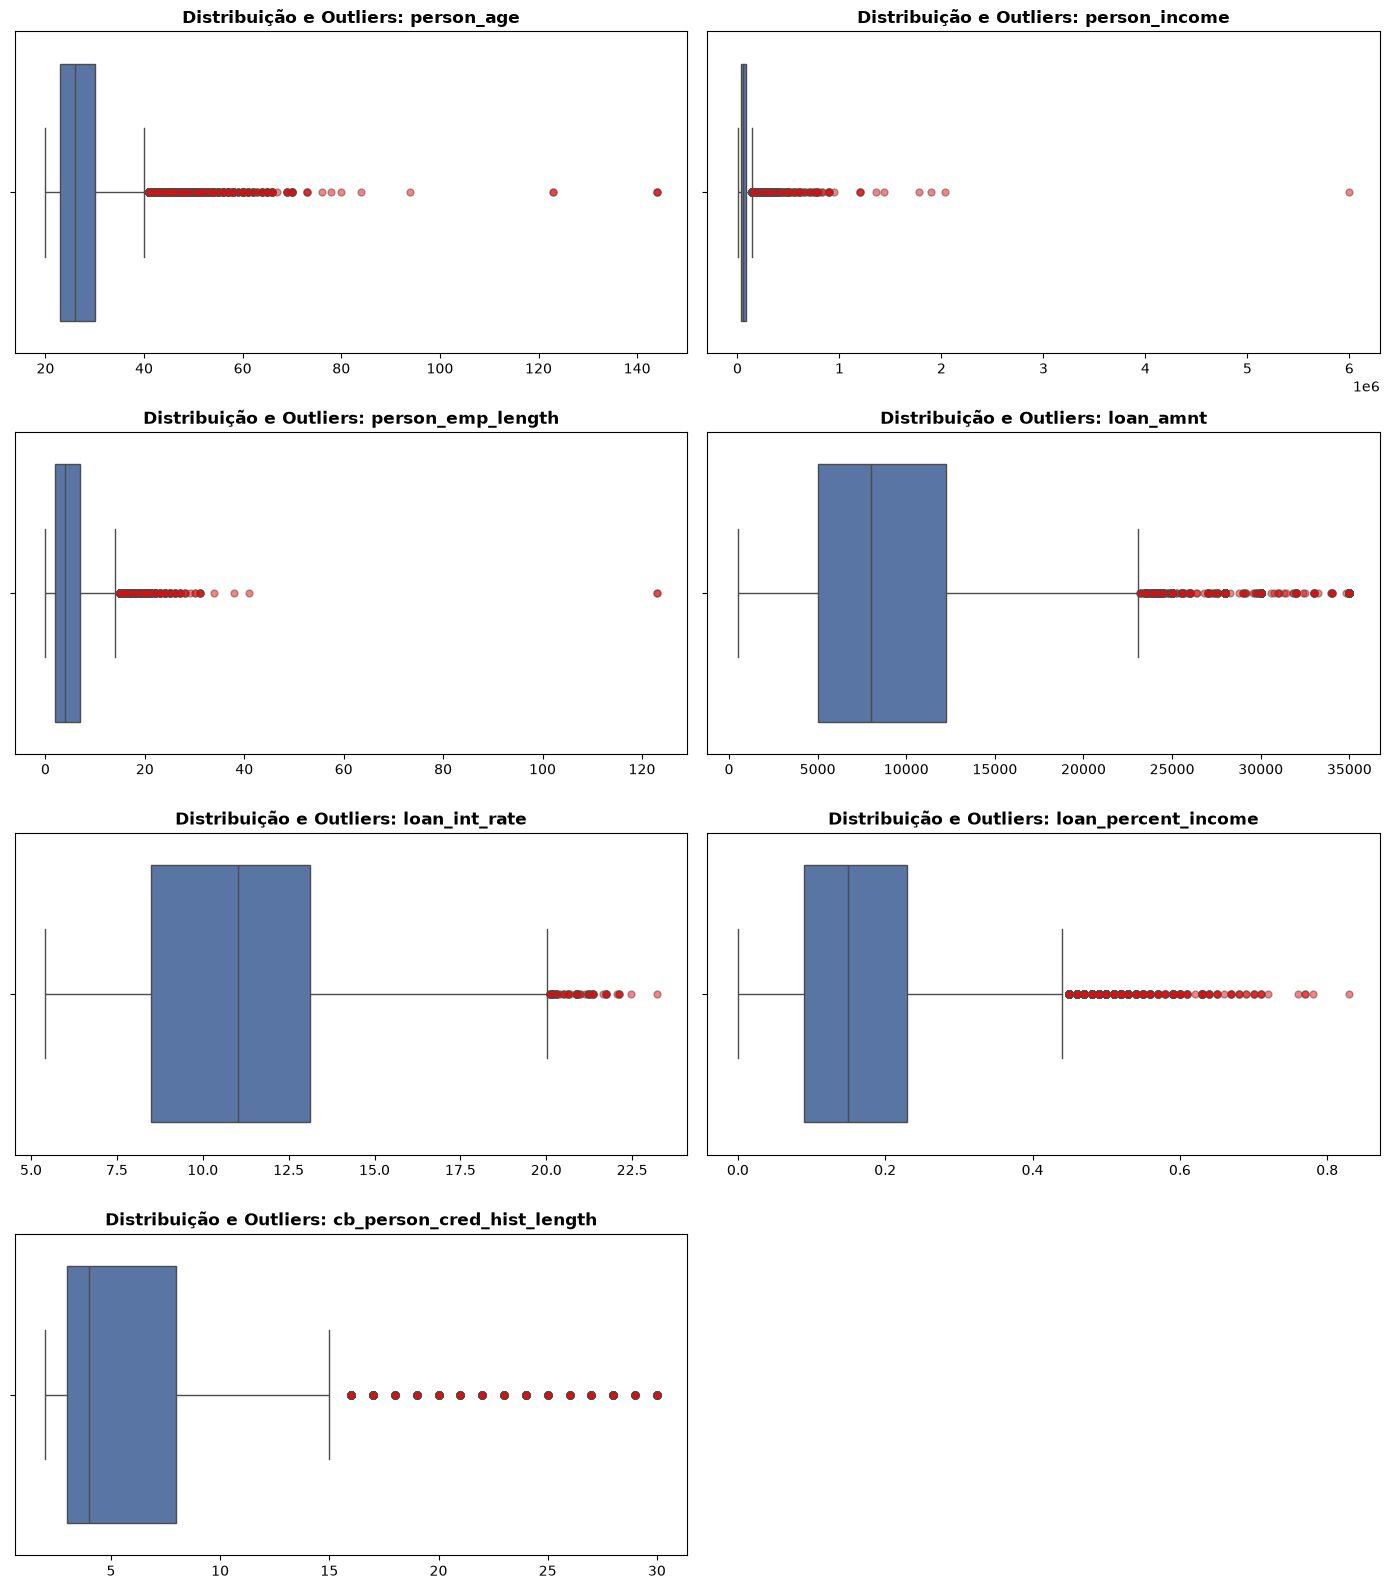

In [14]:
#Boxplot para cada coluna


# Seleciona as colunas numéricas E remove a variável alvo dos boxplots
colunas_continuas = (
    df_credito_novo.select_dtypes(include=["number"])
    .drop(columns=["loan_status"], errors="ignore")
    .columns
)
num_cols = len(colunas_continuas)

plt.figure(figsize=(14, 4 * ((num_cols + 1) // 2)))
estilo_outlier = dict(
    marker="o", markerfacecolor="red", markersize=5, linestyle="none", alpha=0.5
)

for i, col in enumerate(colunas_continuas, 1):
    plt.subplot(((num_cols + 1) // 2), 2, i)
    sns.boxplot(
        x=df_credito_novo[col],
        color="#4c72b0",
        flierprops=estilo_outlier,
        orient="h",
    )
    plt.title(f"Distribuição e Outliers: {col}", fontsize=12, fontweight="bold")
    plt.xlabel("")

plt.tight_layout()
plt.show()

## Decisão sobre Outliers

A análise via boxplots demonstra que a remoção cega por regras estatísticas (como $1.5 \times \text{IQR}$) prejudicaria o negócio. Optou-se pela remoção apenas de ruídos impossíveis (idades > 100 anos), pela manutenção dos outliers comportamentais (alto comprometimento de renda, essenciais para prever inadimplência) e pelo tratamento de escala/clipping em variáveis de cauda longa como Renda. Essa estratégia é vital para o pipeline comparativo: enquanto a Árvore de Decisão isolaria esses nós de risco naturalmente sem sofrer com a escala, o KNN falharia criticamente no cálculo das distâncias euclidianas sem a mitigação da cauda milionária da renda

### Clipping

In [21]:
#1- Cálculo Quartis : Q1-25% e Q3-75% na coluna renda
Q1=df_credito_novo['person_income'].quantile(0.25)
Q3=df_credito_novo['person_income'].quantile(0.75)

#2-Intervalo Interquartil
IQR=Q3-Q1

#3- Limites Inferior e Superior
lower_income=Q1-1.5*IQR
upper_income=Q3+1.5*IQR


#4- Aplicação do método .clip()
df_credito_novo['person_income']=df_credito_novo['person_income'].clip(
    lower=lower_income, upper=upper_income
)


print(f"Limite superior do IQR calculado para Renda: R$ {upper_income:,.2f}")
print(f"Limite inferior do IQR calculado para Renda: R$ {lower_income:,.2f}")

Limite superior do IQR calculado para Renda: R$ 140,232.00
Limite inferior do IQR calculado para Renda: R$ -22,472.00


### Decisão de escolha do Limite Inferior

O cálculo do limite interquartil para a renda gerou um limite inferior de **R$ -22.472,00** e um limite superior de **R$ 140.232,00**. Como rendas negativas são impossíveis no domínio de crédito, o limite inferior foi ajustado para **R$ 0,00** por regra de negócio. Já o truncamento superior em **R$ 140,23 mil** cumpriu o papel vital de eliminar a distorção euclidiana que o extremo de **R$ 6 milhões** causaria no **KNN**, garantindo uma comparação justa com a **Árvore de Decisão** sem perder a escala linear da classe média.

In [29]:
lower_income=0.0
print(f"Clipping aplicado. ! Rendas limitadas entre R$ {lower_income:,.2f} e R$ {upper_income:,.2f}")

Clipping aplicado. ! Rendas limitadas entre R$ 0.00 e R$ 140,232.00
